<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº5

### Melanie amicucci

<br>
</div>

# INTRODUCCIÓN
En este trabajo se realizó el análisis espectral de distintas señales reales mediante la estimación de su densidad espectral de potencia (PSD). La PSD permite observar como se distribuye la potencia de una señal en función de la frecuencia, es decir, en qué componentes frecuenciales se concentra la mayor parte de su energía.

Para obtener esta estimación se utilizó el método de Welch, que consiste en dividir la señal en segmentos, calcular el periodograma de cada uno y luego promediarlos. Este procedimiento permite obtener una estimación más estable y suave que el periodograma tradicional, reduciendo las fluctuaciones propias de una única estimación espectral.

Las señales analizadas fueron una señal de ECG, una señal de PPG, y una señal de audio. 

Para cada una se calculó su PSD y luego se estimó su ancho de banda, el cual se define como el rango de frecuencias donde se concentra la mayor parte de la potencia de la señal.


# Lectura de las señales
En primer lugar, se cargaron las tres señales a analizar. Cada una de estas señales tiene una frecuencia de muestreo distinta, por lo que se definió el valor correspondiente de fs antes de realizar el análisis espectral.

Para el caso del ECG, se utilizó una frecuencia de muestreo de 1000 Hz. La señal fue cargada desde el archivo ecg_sin_ruido.npy mediante la función np.load(). 

En el caso de la señal PPG, se trabajó con una frecuencia de muestreo de 400 Hz. Esta señal también fue cargada desde un archivo .npy

Por último, se cargó la señal de audio correspondiente al archivo la cucaracha.wav. En este caso, la función sio.wavfile.read() permite obtener tanto la frecuencia de muestreo del audio como los datos de la señal.


In [5]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy')
####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz
##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')
####################
# Lectura de audio #
####################

# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')

# Estimación de la PSD mediante WELCH
Para cada una de las señales analizadas se estimó la densidad espectral de potencia mediante el método de Welch. Este método permite observar cómo se distribuye la potencia de cada señal en función de la frecuencia.

En todos los casos se calculó la PSD sin zero padding y también con zero padding, utilizando $ nfft = 5000$. Esto no modifica la información original de la señal, pero permite obtener una representación frecuencial más detallada. Finalmente, las PSD fueron expresadas en dB para facilitar la comparación visual entre ambas estimaciones.


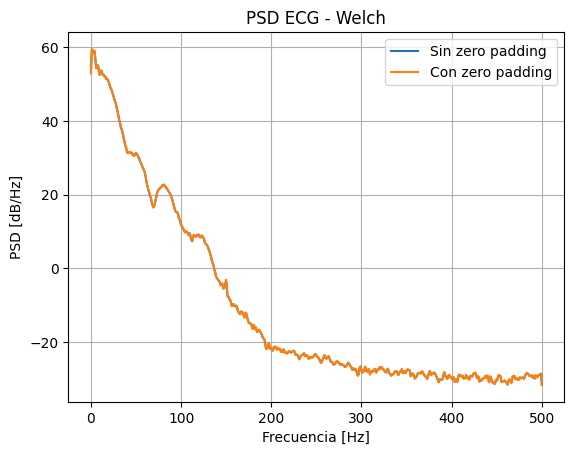

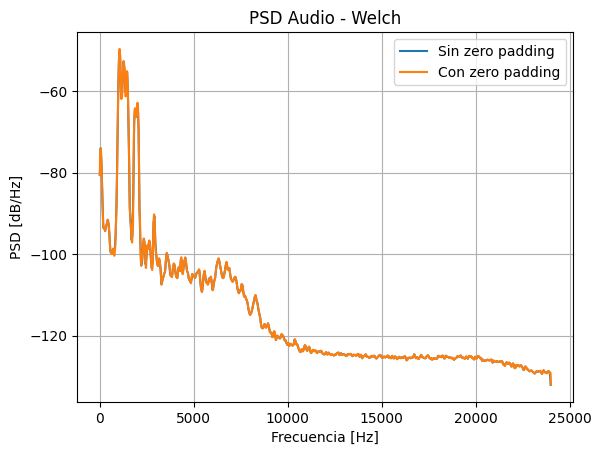

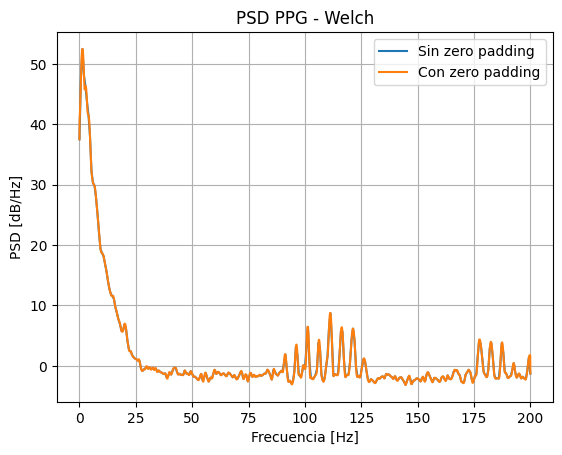

In [6]:
#%% PSD ECG - Welch sin y con zero padding

nperseg_ecg = 1024
nfft = 5000

# Welch sin zero padding
f_ecg, Pxx_ecg = sig.welch(ecg_one_lead, fs_ecg, nperseg=nperseg_ecg)

# Welch con zero padding
f_ecg_zp, Pxx_ecg_zp = sig.welch(ecg_one_lead, fs_ecg, nperseg=nperseg_ecg, nfft=nfft)

# Paso a dB para graficar
Pxx_ecg_dB = 10 * np.log10(Pxx_ecg)
Pxx_ecg_zp_dB = 10 * np.log10(Pxx_ecg_zp)

plt.figure()
plt.plot(f_ecg, Pxx_ecg_dB, label='Sin zero padding')
plt.plot(f_ecg_zp, Pxx_ecg_zp_dB, label='Con zero padding')
plt.title('PSD ECG - Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid()
plt.legend()
plt.show()

#%% PSD AUDIO - Welch sin y con zero padding

# Si el audio tiene dos canales, me quedo con uno solo
if wav_data.ndim > 1:
    audio = wav_data[:, 0]
else:
    audio = wav_data

nperseg_audio = 1024
nfft = 5000

# Welch sin zero padding
f_audio, Pxx_audio = sig.welch(audio, fs_audio, nperseg=nperseg_audio)

# Welch con zero padding
f_audio_zp, Pxx_audio_zp = sig.welch(audio, fs_audio, nperseg=nperseg_audio, nfft=nfft)

# Paso a dB para graficar
Pxx_audio_dB = 10 * np.log10(Pxx_audio)
Pxx_audio_zp_dB = 10 * np.log10(Pxx_audio_zp)

plt.figure()
plt.plot(f_audio, Pxx_audio_dB, label='Sin zero padding')
plt.plot(f_audio_zp, Pxx_audio_zp_dB, label='Con zero padding')
plt.title('PSD Audio - Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid()
plt.legend()
plt.show()
#%% PSD PPG - Welch sin y con zero padding

nperseg_ppg = 600
nfft = 5000

# Welch sin zero padding
f_ppg, Pxx_ppg = sig.welch(ppg, fs_ppg, nperseg=nperseg_ppg)

# Welch con zero padding
f_ppg_zp, Pxx_ppg_zp = sig.welch(ppg, fs_ppg, nperseg=nperseg_ppg, nfft=nfft)

# Paso a dB para graficar
Pxx_ppg_dB = 10 * np.log10(Pxx_ppg)
Pxx_ppg_zp_dB = 10 * np.log10(Pxx_ppg_zp)

plt.figure()
plt.plot(f_ppg, Pxx_ppg_dB, label='Sin zero padding')
plt.plot(f_ppg_zp, Pxx_ppg_zp_dB, label='Con zero padding')
plt.title('PSD PPG - Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid()
plt.legend()
plt.show()

# Estimación del ancho de banda 
Una vez obtenida la PSD de cada señal, se estimó su ancho de banda a partir de la potencia acumulada. Para esto se utilizó la PSD calculada con zero padding, ya que facilita la ubicación de la frecuencia de corte.

Para las señales ECG y PPG se consideró que la mayor parte de la energía se concentra desde bajas frecuencias comportandose como un pasabajos. Por eso, se calculó la potencia total de la PSD y luego se fue acumulando desde 0 Hz hasta encontrar la frecuencia en la cual se alcanza el 95% de la potencia total. Esa frecuencia se tomó como el ancho de banda estimado de la señal.

En el caso del audio, se utilizó un criterio distinto, ya que la energía no necesariamente comienza desde 0 Hz. Por este motivo, se buscó el intervalo de frecuencias comprendido entre el 2,5% y el 97,5% de la potencia acumulada. Luego, el ancho de banda se calculó como la diferencia entre la frecuencia superior y la frecuencia inferior de ese intervalo.



Ancho de banda ECG: 22.8 Hz


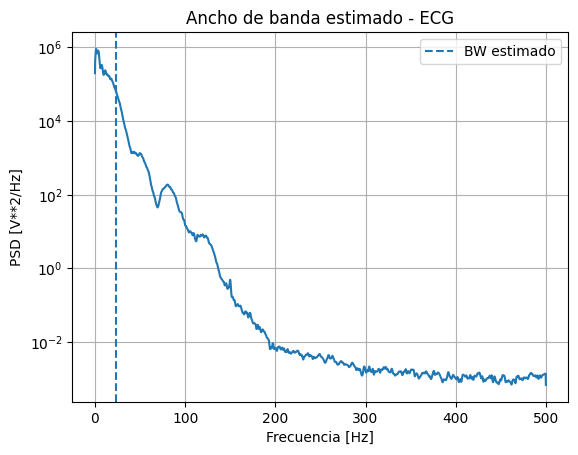

Ancho de banda PPG: 3.92 Hz


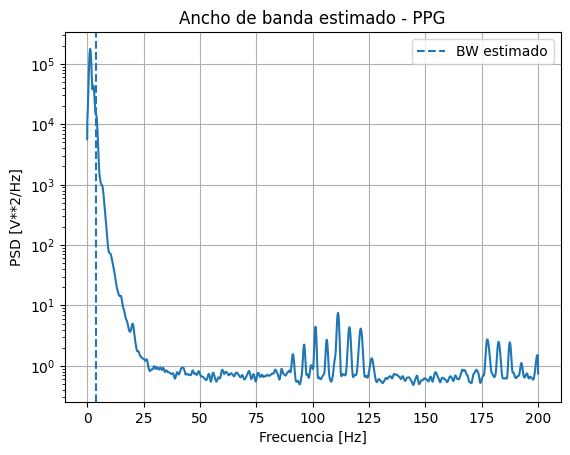

Ancho de banda audio: 950.4000000000001 Hz


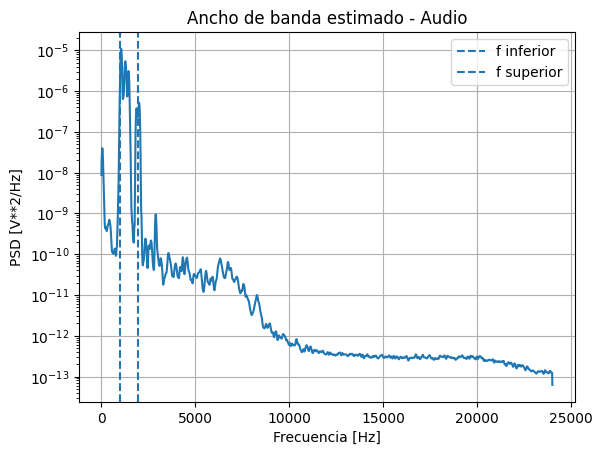

In [8]:
#%% ECG - Ancho de banda

potencia_total_ecg = np.sum(Pxx_ecg_zp)

potencia_acumulada_ecg = 0
indice_corte_ecg = 0

for i in range(len(Pxx_ecg_zp)):
    
    potencia_acumulada_ecg = potencia_acumulada_ecg + Pxx_ecg_zp[i]
    
    porcentaje_ecg = potencia_acumulada_ecg / potencia_total_ecg
    
    if porcentaje_ecg >= 0.95:
        indice_corte_ecg = i
        break

bw_ecg = f_ecg_zp[indice_corte_ecg]

print("Ancho de banda ECG:", bw_ecg, "Hz")


plt.figure()
plt.semilogy(f_ecg_zp, Pxx_ecg_zp)
plt.axvline(bw_ecg, linestyle='--', label='BW estimado')
plt.title('Ancho de banda estimado - ECG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid()
plt.legend()
plt.show()
#%% PPG - Ancho de banda

potencia_total_ppg = np.sum(Pxx_ppg_zp)

potencia_acumulada_ppg = 0
indice_corte_ppg = 0

for i in range(len(Pxx_ppg_zp)):
    
    potencia_acumulada_ppg = potencia_acumulada_ppg + Pxx_ppg_zp[i]
    
    porcentaje_ppg = potencia_acumulada_ppg / potencia_total_ppg
    
    if porcentaje_ppg >= 0.95:
        indice_corte_ppg = i
        break

bw_ppg = f_ppg_zp[indice_corte_ppg]

print("Ancho de banda PPG:", bw_ppg, "Hz")


plt.figure()
plt.semilogy(f_ppg_zp, Pxx_ppg_zp)
plt.axvline(bw_ppg, linestyle='--', label='BW estimado')
plt.title('Ancho de banda estimado - PPG')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid()
plt.legend()
plt.show()
#%% AUDIO - Ancho de banda

potencia_total_audio = np.sum(Pxx_audio_zp)

potencia_acumulada_audio = 0

indice_inferior_audio = 0
indice_superior_audio = 0

encontre_inferior = False

for i in range(len(Pxx_audio_zp)):
    
    potencia_acumulada_audio = potencia_acumulada_audio + Pxx_audio_zp[i]
    
    porcentaje_audio = potencia_acumulada_audio / potencia_total_audio
    
    if porcentaje_audio >= 0.025 and encontre_inferior == False:
        indice_inferior_audio = i
        encontre_inferior = True
    
    if porcentaje_audio >= 0.975:
        indice_superior_audio = i
        break

f_min_audio = f_audio_zp[indice_inferior_audio]
f_max_audio = f_audio_zp[indice_superior_audio]

bw_audio = f_max_audio - f_min_audio

print("Ancho de banda audio:", bw_audio, "Hz")


plt.figure()
plt.semilogy(f_audio_zp, Pxx_audio_zp)
plt.axvline(f_min_audio, linestyle='--', label='f inferior')
plt.axvline(f_max_audio, linestyle='--', label='f superior')
plt.title('Ancho de banda estimado - Audio')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid()
plt.legend()
plt.show()

# Tabla de comparación

Finalmente, se organizaron los resultados obtenidos en una tabla para facilitar la comparación entre las señales analizadas. En esta tabla se incluyen la frecuencia de muestreo de cada señal, el valor de $nperseg$ utilizado en Welch, el valor de $nfft$ empleado para el zero padding, las frecuencias límite consideradas y el ancho de banda estimado.

En el caso de ECG y PPG, como se asumió que la energía principal comienza en bajas frecuencias, la frecuencia mínima se tomó como 0 Hz. Para el audio, en cambio, se consideró un intervalo de energía entre una frecuencia inferior y una frecuencia superior, por lo que el ancho de banda se obtuvo como la diferencia entre ambas.

Esta tabla permite comparar de forma resumida el contenido frecuencial de las tres señales y observar que cada una presenta un ancho de banda distinto según su naturaleza y su frecuencia de muestreo.


In [10]:
#%% TABLA FINAL

print("")
print("TABLA FINAL DE RESULTADOS")
print("--------------------------------------------------------------------------")
print("Señal\t\tfs [Hz]\tnperseg\tnfft\tf min [Hz]\tf max [Hz]\tBW [Hz]")
print("--------------------------------------------------------------------------")

print("ECG\t\t", fs_ecg, "\t", nperseg_ecg, "\t\t", nfft, "\t",
      0, "\t\t", round(bw_ecg, 2), "\t\t", round(bw_ecg, 2))

print("PPG\t\t", fs_ppg, "\t", nperseg_ppg, "\t\t", nfft, "\t",
      0, "\t\t", round(bw_ppg, 2), "\t\t", round(bw_ppg, 2))

print("Audio\t\t", fs_audio, "\t", nperseg_audio, "\t\t", nfft, "\t",
      round(f_min_audio, 2), "\t\t", round(f_max_audio, 2), "\t\t", round(bw_audio, 2))


TABLA FINAL DE RESULTADOS
--------------------------------------------------------------------------
Señal		fs [Hz]	nperseg	nfft	f min [Hz]	f max [Hz]	BW [Hz]
--------------------------------------------------------------------------
ECG		 1000 	 1024 		 5000 	 0 		 22.8 		 22.8
PPG		 400 	 600 		 5000 	 0 		 3.92 		 3.92
Audio		 48000 	 1024 		 5000 	 998.4 		 1948.8 		 950.4


## Análisis de resultados

A partir de las PSD obtenidas mediante Welch se observa que cada señal concentra su potencia en rangos de frecuencia diferentes. En el caso del ECG y la PPG, la mayor parte de la energía se encuentra en bajas frecuencias, lo cual es esperable porque son señales de variación lenta. Por eso, su ancho de banda estimado resulta menor en comparación con la señal de audio.

En la señal de audio se observa un contenido frecuencial más amplio, ya que este tipo de señal presenta variaciones más rápidas y componentes distribuidas en un rango mayor de frecuencias. Por este motivo, para el audio se estimó un intervalo entre una frecuencia mínima y una frecuencia máxima, obteniendo un ancho de banda mayor.

La comparación entre las PSD sin zero padding y con zero padding muestra que la forma general del espectro se mantiene, pero con $nfft = 5000$ se obtiene una representación más detallada en frecuencia. Esto facilitó la estimación visual y numérica del ancho de banda de cada señal.
